# A gradient echo on a spiral, assembled here

`sc.modules.SpiralReadout` is **one arm**. A scan is that arm, an excitation in front of it, and a
list of angles — and this notebook writes those three lines rather than importing a class that
hides them. There is deliberately **no `GRESpiral2D`**: strip the angle list out and what remains
is a spoiled gradient echo whose readout happens to be a spiral.

The point of the notebook is the join. `SpiralReadout` says **where the trajectory crosses the
origin**; it does not and must not say where the *echo* is. Aligning the physical echo with the
intended crossing is this layer's job, and getting it wrong produces a legal sequence with the
wrong TE — which is exactly the failure the historical spiral work recorded.

**Output:** one `.seq` file, an eight-interleaf spiral GRE.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=38, grad_unit='mT/m',
    max_slew=140, slew_unit='T/m/s',
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
    adc_samples_limit=8192,
)

FOV_MM, MATRIX, THICKNESS_MM = 240.0, 64, 5.0
SHOTS, FLIP_DEG, TR_S = 8, 15.0, 30e-3
DUMMIES = 4

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The two pieces

The readout is designed once. `shots` enters the **path** — the Nyquist condition is
`dθ/dr = 2π·FOV(r)/shots` — so one interleaf of an eight-shot spiral is a different curve from one
interleaf of a four-shot spiral, not the same curve rotated. The rotation comes later and is a
separate thing.

In [2]:
exc = sc.modules.Excitation(opts=opts, flip_deg=FLIP_DEG, thickness_mm=THICKNESS_MM,
                            duration_s=1e-3)
spiral = sc.modules.SpiralReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=SHOTS,
                                  dwell_s=4e-6, variant='out')
spoil = sc.modules.spoiler(opts, cycles_per_voxel=4.0, voxel_mm=THICKNESS_MM, axis='z')

print(f'excitation      {exc().duration * 1e3:.3f} ms, centre at {exc.time_to_center() * 1e3:.3f} ms')
print(f'spiral arm      {spiral.duration_s * 1e3:.3f} ms, {spiral.num_samples} samples in '
      f'{len(spiral._segments)} ADC event(s)')
print(f'k_max           {spiral.k_max_per_m:.1f} 1/m   dk {spiral.dk_per_m:.3f} 1/m')
print(f'origin crossing sample {spiral.origin_crossing_samples}, at '
      f'{spiral.time_to_echo(0) * 1e6:.1f} us into the readout block')
print(f'prephase needed {spiral.needs_prephase}   rewind needed {spiral.needs_rewind}')

excitation      1.840 ms, centre at 0.640 ms
spiral arm      2.770 ms, 684 samples in 1 ADC event(s)
k_max           133.3 1/m   dk 4.167 1/m
origin crossing sample (0,), at 12.0 us into the readout block
prephase needed False   rewind needed True


`variant='out'` starts at the centre of k-space, so its single origin crossing is the **first**
sample and no prephaser is required. It ends at `k_max`, so a rewinder is — and the module states
that requirement and realises it by default.

## TE is owned here, not by the readout

This is the line the whole notebook exists for.

```text
SpiralReadout  owns:  where the trajectory crosses the origin
this layer     owns:  whether the physical echo lands on that crossing
```

So TE is measured from the excitation's **effective centre** to the crossing the readout reports.
Neither number is guessed: both modules report their own, and this cell adds them.

In [3]:
start_s = float(raster.ceil(exc().duration))
te_s = start_s + spiral.time_to_echo(0) - exc.time_to_center()

print(f'readout starts at   {start_s * 1e3:.3f} ms')
print(f'  + crossing offset {spiral.time_to_echo(0) * 1e6:.1f} us')
print(f'  - RF centre       {exc.time_to_center() * 1e3:.3f} ms')
print(f'  = TE              {te_s * 1e3:.3f} ms')

readout starts at   1.840 ms
  + crossing offset 12.0 us
  - RF centre       0.640 ms
  = TE              1.212 ms


## One repetition, and the angle schedule

Four lines, and the schedule is a list comprehension. `angle_rad` is a per-call argument, so the
same readout instance serves every interleaf — the same precedent `RadialReadout` set.

In [4]:
def angles(n):
    """Equal increments over 2 pi: the interleaves of one spiral."""
    return [2.0 * np.pi * i / n for i in range(n)]


def phase_deg(n, increment=117.0):
    """RF spoiling, quadratic in the repetition index."""
    return 0.5 * increment * n * (n + 1)


def repetition(angle_rad, *, phase, acquire=True):
    """Excite, play one interleaf, spoil, fill to TR."""
    out = sc.LogicBlock('spiral_tr').add(0.0, exc(phase_deg=phase))
    out.add(start_s, spiral(angle_rad=angle_rad, acquire=acquire, phase_deg=phase))
    tail = start_s + spiral(angle_rad=angle_rad).duration
    out.add(tail, spoil)
    fill = float(raster.ceil(TR_S - tail - spoil.duration))
    if fill > 1e-9:
        out.add(tail + spoil.duration, pp.make_delay(fill))
    return out


scan = sc.LogicBlock('gre_spiral_2d')
for index in range(DUMMIES):
    scan.add(index * TR_S, repetition(0.0, phase=phase_deg(index), acquire=False))
for index, angle in enumerate(angles(SHOTS)):
    n = DUMMIES + index
    scan.add(n * TR_S, repetition(angle, phase=phase_deg(n)))

print(f'{SHOTS} interleaves + {DUMMIES} dummies, {scan.duration:.3f} s')
print(f'TR {repetition(0.0, phase=0.0).duration * 1e3:.3f} ms')

8 interleaves + 4 dummies, 0.360 s
TR 30.000 ms


## What the acquisition encodes

Measured off the **compiled** sequence, not off the design. `sc.kspace` shares no code with the
readout module, so this is a check rather than a restatement.

In [5]:
seq = sc.compile(scan, opts, name='gre_spiral_2d', definitions={
    'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
    'TE': te_s, 'TR': TR_S,
})
seq.write(str(SEQ_DIR / 'gre_spiral_2d.seq'))

field = sc.kspace(scan, opts)
k = field['k_adc'][:2].reshape(2, SHOTS, spiral.num_samples)
t_adc = field['t_adc']
radius = np.linalg.norm(k, axis=0)

print(f'{len(seq.block_events)} blocks, {seq.duration()[0]:.3f} s -> seq/gre_spiral_2d.seq')
print()
print(f'|k| at the reported crossing   {radius[:, spiral.echo_sample(0)].max():.4f} 1/m '
      f'= {radius[:, spiral.echo_sample(0)].max() / spiral.dk_per_m:.4f} dk')
print(f'k_max reached                  {radius.max():.2f} 1/m (asked for {spiral.k_max_per_m:.2f})')
print(f'k at the end of every arm      {radius[:, -1].max():.2f} 1/m')

72 blocks, 0.360 s -> seq/gre_spiral_2d.seq

|k| at the reported crossing   0.4130 1/m = 0.0991 dk
k_max reached                  133.25 1/m (asked for 133.33)
k at the end of every arm      133.25 1/m


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_58723/803543349.py:1: SeqCraftWarning: 4 blocks over the vector-norm limit (legal on real amplifiers): gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 154.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 214.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 274.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 334.610 ms)
  seq = sc.compile(scan, opts, name='gre_spiral_2d', definitions={
/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:201: SeqCraftWarning: 4 blocks over the vector-norm limit (legal on real amplifiers): gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 154.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 214.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 274.610 ms), gre_spiral_2d.spiral_tr.SpiralReadout (slew 139% at 334.610 ms)
  seq = compile_sequence(tree, opts)
/opt/homebrew/Caskroom/miniforge/base/envs/seq

The crossing is inside a sampling window and within a small fraction of one Nyquist step of the
origin — measured on the compiled file, per interleaf.

### The alignment check this notebook exists for

The RF centre of each repetition and the origin crossing of its readout must be `TE` apart. Read
both off the compiled sequence and subtract: if the composition placed the readout against the
wrong instant, this is where it shows, and nothing else in the file would look wrong.

In [6]:
# Both sides read off the compiled sequence: the excitation instants and the sample times come
# from sc.kspace, which shares no code with either module.  Nothing here restates the arithmetic
# that placed the readout.
rf_centres = field['t_excitation'][-SHOTS:]
crossings = t_adc.reshape(SHOTS, spiral.num_samples)[:, spiral.echo_sample(0)]
measured_te = crossings - rf_centres

print(f'{"shot":>5}  {"RF centre / ms":>15}  {"crossing / ms":>14}  {"TE / ms":>9}')
for shot, (centre, cross, te) in enumerate(zip(rf_centres, crossings, measured_te)):
    print(f'{shot:5d}  {centre * 1e3:15.4f}  {cross * 1e3:14.4f}  {te * 1e3:9.4f}')
print()
print(f'TE spread across interleaves   {np.ptp(measured_te) * 1e9:.3f} ns')
print(f'against the reported TE        {abs(measured_te.mean() - te_s) * 1e9:.3f} ns')


 shot   RF centre / ms   crossing / ms    TE / ms
    0         120.6400        121.8520     1.2120
    1         150.6400        151.8520     1.2120
    2         180.6400        181.8520     1.2120
    3         210.6400        211.8520     1.2120
    4         240.6400        241.8520     1.2120
    5         270.6400        271.8520     1.2120
    6         300.6400        301.8520     1.2120
    7         330.6400        331.8520     1.2120

TE spread across interleaves   0.000 ns
against the reported TE        0.000 ns


## The interleaves are one contract, rotated

In [7]:
wanted = np.degrees(angles(SHOTS))
measured = np.degrees(np.arctan2(k[1, :, -1], k[0, :, -1]) - np.arctan2(k[1, 0, -1], k[0, 0, -1]))
print(f'angle error across {SHOTS} interleaves   '
      f'{np.abs((measured - wanted + 180) % 360 - 180).max():.3e} deg')
print(f'extent spread across interleaves  {np.ptp(radius.max(axis=1)):.3e} 1/m')
print(f'samples per interleaf             {spiral.num_samples} (identical by construction)')

angle error across 8 interleaves   5.684e-13 deg
extent spread across interleaves  1.222e-12 1/m
samples per interleaf             684 (identical by construction)


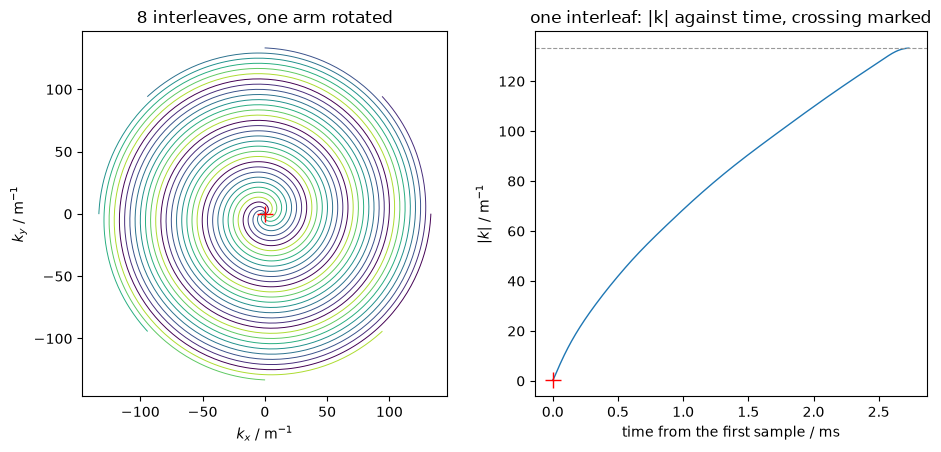

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))
for shot in range(SHOTS):
    axes[0].plot(k[0, shot], k[1, shot], lw=0.7, color=plt.cm.viridis(shot / SHOTS))
axes[0].plot(0, 0, 'r+', ms=11)
axes[0].set(title=f'{SHOTS} interleaves, one arm rotated', xlabel='$k_x$ / m$^{-1}$',
            ylabel='$k_y$ / m$^{-1}$', aspect='equal')

axes[1].plot((t_adc[:spiral.num_samples] - t_adc[0]) * 1e3, radius[0], lw=1.0)
axes[1].axhline(spiral.k_max_per_m, color='0.6', ls='--', lw=0.8)
axes[1].plot(0.0, radius[0, spiral.echo_sample(0)], 'r+', ms=11)
axes[1].set(title='one interleaf: |k| against time, crossing marked',
            xlabel='time from the first sample / ms', ylabel='$|k|$ / m$^{-1}$')
fig.tight_layout()

## A single-shot variant, for the off-resonance notebook

`shots` enters the **path**, so this is not the eight-interleaf arm played once — it is a
different curve, eight times longer, and that length is the whole reason
[`02`](02_simulate_and_reconstruct.ipynb) exists. Off-resonance evolves *during* a readout, so
what it does to an image is set by how long the readout is.

One interleaf, one excitation, otherwise the same composition.

In [9]:
single = sc.modules.SpiralReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=1,
                                  dwell_s=4e-6, variant='out')
single_te_s = start_s + single.time_to_echo(0) - exc.time_to_center()


def single_repetition(*, phase, acquire=True):
    """The same four lines, with the one-shot arm."""
    out = sc.LogicBlock('spiral_tr').add(0.0, exc(phase_deg=phase))
    out.add(start_s, single(angle_rad=0.0, acquire=acquire, phase_deg=phase))
    tail = start_s + single(angle_rad=0.0).duration
    out.add(tail, spoil)
    fill = float(raster.ceil(TR_S - tail - spoil.duration))
    if fill > 1e-9:
        out.add(tail + spoil.duration, pp.make_delay(fill))
    return out


single_scan = sc.LogicBlock('gre_spiral_2d_singleshot')
for index in range(DUMMIES):
    single_scan.add(index * TR_S, single_repetition(phase=phase_deg(index), acquire=False))
single_scan.add(DUMMIES * TR_S, single_repetition(phase=phase_deg(DUMMIES)))

single_seq = sc.compile(single_scan, opts, name='gre_spiral_2d_singleshot', definitions={
    'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
    'TE': single_te_s, 'TR': TR_S,
})
single_seq.write(str(SEQ_DIR / 'gre_spiral_2d_singleshot.seq'))

print(f'{"":14s} {"shots":>5s} {"readout / ms":>12s} {"samples":>8s} {"ADC events":>10s}')
print(f'{"interleaved":14s} {SHOTS:5d} {spiral.duration_s * 1e3:12.3f} '
      f'{spiral.num_samples:8d} {len(spiral._segments):10d}')
print(f'{"single shot":14s} {1:5d} {single.duration_s * 1e3:12.3f} '
      f'{single.num_samples:8d} {len(single._segments):10d}')
print()
print(f'a 100 Hz offset turns {spiral.duration_s * 100:.2f} cycles over the interleaved readout '
      f'and {single.duration_s * 100:.2f} over the single-shot one')
print(f'-> seq/gre_spiral_2d_singleshot.seq, {len(single_seq.block_events)} blocks')

               shots readout / ms  samples ADC events
interleaved        8        2.770      684          1
single shot        1       21.710     5420          1

a 100 Hz offset turns 0.28 cycles over the interleaved readout and 2.17 over the single-shot one
-> seq/gre_spiral_2d_singleshot.seq, 30 blocks


## What this notebook established

| | |
|---|---|
| a spiral GRE is **one arm plus a schedule** | which is why no `GRESpiral2D` ships — it would own the angle list and no physics |
| **TE is owned here** | measured from the excitation's effective centre to the crossing the readout reports, with both numbers read off their own modules |
| the echo lands where it was placed | TE identical across interleaves to nanoseconds, and matching the reported value |
| interleaves are one contract, rotated | angle error below 1e-12 degrees, identical extent and sample count |
| the crossing is inside a sampling window | measured on the compiled file, a small fraction of `dk` from the origin |
| the whole acquisition compiles | two `.seq` files, legal Pulseq |
| `shots` changes the **path**, not just the rotation | the single-shot arm is 21.7 ms against 2.77 ms for one interleaf of eight — a different curve, not the same one played once |

[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) reconstructs both
files. It is the off-resonance notebook: the single-shot readout is 7.9x longer than one
interleaf, and that length is what a spiral pays for its speed. The shared reconstruction
path it uses is [`../noncartesian_recon.py`](../noncartesian_recon.py), introduced in
[`../gre_radial_2d/02`](../gre_radial_2d/02_simulate_and_reconstruct.ipynb) and unchanged
here.
